# Extreme Value Type I (Gumbel) Distribution

The **Gumbel (Extreme Value Type I) distribution** models the maximum (or minimum) of a large collection of independent variables. It is the natural distribution for the largest value in a sample — flood levels, wind speeds, maximum temperatures, material breaking strengths.

| Property | Value |
|---|---|
| **Parameters** | μ (location), β (scale, β > 0) |
| **Support** | (−∞, +∞) |
| **PDF (max)** | f(x) = (1/β) exp(−z − e^(−z)), z=(x−μ)/β |
| **CDF (max)** | F(x) = exp(−exp(−(x−μ)/β)) |
| **Mean** | μ + 0.5772β (Euler–Mascheroni constant) |
| **Median** | μ − β ln(ln 2) |
| **Mode** | μ |
| **Std Dev** | βπ/√6 |
| **Skewness** | 1.14 (always right-skewed for max case) |
| **Kurtosis** | 5.4 (heavy tails) |
| **Estimation** | MOM: μ̂ = x̄ − 0.5772β̂, β̂ = s√6/π |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

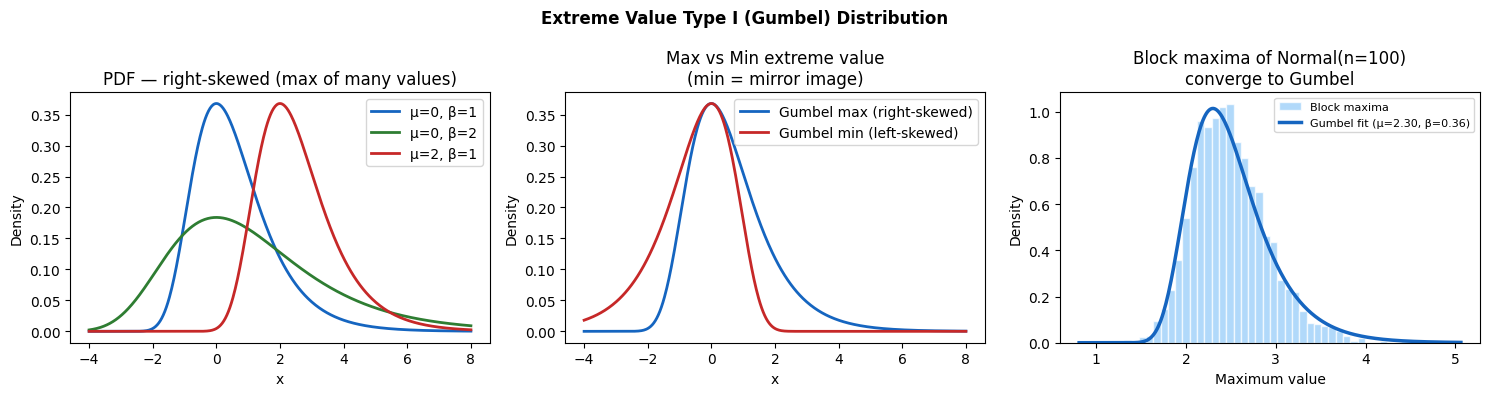

Block maxima: mean=2.496, std=0.416
Gumbel fit: μ=2.300, β=0.363


In [2]:
# scipy: stats.gumbel_r = max (right-skewed), stats.gumbel_l = min (left-skewed)
x = np.linspace(-4, 8, 500)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Extreme Value Type I (Gumbel) Distribution', fontsize=12, fontweight='bold')

# PDF
for mu, beta, color, label in [(0, 1,   '#1565C0', 'μ=0, β=1'),
                                (0, 2,   '#2E7D32', 'μ=0, β=2'),
                                (2, 1,   '#C62828', 'μ=2, β=1')]:
    axes[0].plot(x, stats.gumbel_r(loc=mu, scale=beta).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — right-skewed (max of many values)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend()

# Max and min variants
axes[1].plot(x, stats.gumbel_r(0,1).pdf(x), color='#1565C0', linewidth=2, label='Gumbel max (right-skewed)')
axes[1].plot(x, stats.gumbel_l(0,1).pdf(x), color='#C62828', linewidth=2, label='Gumbel min (left-skewed)')
axes[1].set_title('Max vs Min extreme value\n(min = mirror image)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Density')
axes[1].legend()

# Extreme value convergence: max of n normals → Gumbel
np.random.seed(42)
n_obs = 100    # sample size per block
n_blocks = 2000
block_maxima = [np.max(np.random.normal(0, 1, n_obs)) for _ in range(n_blocks)]
block_maxima = np.array(block_maxima)

# Fit Gumbel
loc_fit, scale_fit = stats.gumbel_r.fit(block_maxima)[:2]

axes[2].hist(block_maxima, bins=40, density=True, color='#90CAF9', edgecolor='white',
             alpha=0.7, label='Block maxima')
x_fit = np.linspace(block_maxima.min()-0.5, block_maxima.max()+0.5, 300)
axes[2].plot(x_fit, stats.gumbel_r(loc=loc_fit, scale=scale_fit).pdf(x_fit),
             color='#1565C0', linewidth=2.5, label=f'Gumbel fit (μ={loc_fit:.2f}, β={scale_fit:.2f})')
axes[2].set_title(f'Block maxima of Normal(n={n_obs})\nconverge to Gumbel')
axes[2].set_xlabel('Maximum value'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Block maxima: mean={block_maxima.mean():.3f}, std={block_maxima.std():.3f}")
print(f"Gumbel fit: μ={loc_fit:.3f}, β={scale_fit:.3f}")

## Key Takeaways

| | |
|---|---|
| **EVT** | Block maxima from any distribution with exponential-like tails converge to Gumbel |
| **Right-skewed** | Skewness=1.14 — heavy right tail (extreme max events) |
| **Mode=μ** | The mode is the location parameter — peak is at μ |
| **Mean** | μ + γβ where γ≈0.5772 (Euler–Mascheroni constant) |
| **Max vs Min** | Gumbel_r for maxima, Gumbel_l for minima (mirror image) |
| **Return period** | P(X > x) = 1 − exp(−exp(−(x−μ)/β)) → T-year flood level |
| **Use cases** | Flood levels, wind speeds, earthquake magnitudes, stock losses |